# PM2.5 Prediction Model

**Input:** `df_model_monthly.csv` built in `features.ipynb`.

| Model | Algorithm | Features                                              | Goal |
|---|---|-------------------------------------------------------|---|
| **A** | RF + XGBoost | environmental, spatial, contextual variables          | Policy story: what can municipalities act on? |
| **B** | RF | PM2.5 lags, rolling features, lagged pollutants, weather, context | Accuracy benchmark |
| **C** | Ridge | Same as A                                             | Linear baseline with signed coefficients |

**Two splits:** time (train past / test future) and spatial (train on some stations / test on unseen stations).

**Primary outputs:** files in `model_output/` consumed by `policy_translation.ipynb`.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.base import clone
from xgboost import XGBRegressor
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
print("Libraries loaded")


Libraries loaded


## Load final modeling dataset

This CSV was created in `features.ipynb` and already contains:
- date
- station identifier (`eoi_code`)
- weather/context variables
- lag features
- rolling features

For now, we only use the columns needed for Model A.

In [2]:
df = pd.read_csv("df_model_monthly.csv", parse_dates=["date"])

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Stations:", df["eoi_code"].nunique())

display(df.head())

Shape: (3986, 33)
Date range: 2020-01-01 00:00:00 to 2025-11-01 00:00:00
Stations: 144


,eoi_code,date,Year,Month,Season,PM2_5,PM10,NO2,O3,PM2_5_lag1,PM2_5_lag2,PM2_5_lag3,PM2_5_roll3_mean,PM2_5_roll3_std,PM10_lag1,NO2_lag1,O3_lag1,Temp_Mean,Wind_Speed,Precipitation,Temp_Mean_lag1,Wind_Speed_lag1,Precipitation_lag1,Altitude,Latitude,Longitude,Station_Type,Station_Area,City,Green_Ratio,Population_Density,month_sin,month_cos
0,IT0459A,2020-04-01,2020,4,Spring,8.32,21.4,24.4,54.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.490000,10.310000,44.6,NaN,NaN,NaN,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,8.660254e-01,-0.500000
1,IT0459A,2020-05-01,2020,5,Spring,6.41,19.7,25.1,56.7,8.32,NaN,NaN,NaN,NaN,21.4,24.4,54.1,18.061290,10.125806,62.0,13.490000,10.310000,44.6,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,5.000000e-01,-0.866025
2,IT0459A,2020-06-01,2020,6,Summer,8.42,21.6,23.9,61.4,6.41,8.32,NaN,NaN,NaN,19.7,25.1,56.7,21.836667,9.896667,59.2,18.061290,10.125806,62.0,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,1.224647e-16,-1.000000
3,IT0459A,2020-07-01,2020,7,Summer,8.13,20.4,20.1,56.5,8.42,6.41,8.32,7.716667,1.132711,21.6,23.9,61.4,24.532258,9.580645,28.6,21.836667,9.896667,59.2,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-5.000000e-01,-0.866025
4,IT0459A,2020-08-01,2020,8,Summer,7.74,20.0,27.2,53.0,8.13,8.42,6.41,7.653333,1.086477,20.4,20.1,56.5,25.606452,10.080645,65.2,24.532258,9.580645,28.6,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-8.660254e-01,-0.500000


In [3]:
# Ensuring target exists, date is datetime, station id exists, PM2.5 has non-missing values
print("Target missing:", df["PM2_5"].isna().sum())
print("Date dtype:", df["date"].dtype)
print("Station id missing:", df["eoi_code"].isna().sum())

display(df[["date", "eoi_code", "PM2_5"]].head())

Target missing: 0
Date dtype: datetime64[ns]
Station id missing: 0


,date,eoi_code,PM2_5
0,2020-04-01,IT0459A,8.32
1,2020-05-01,IT0459A,6.41
2,2020-06-01,IT0459A,8.42
3,2020-07-01,IT0459A,8.13
4,2020-08-01,IT0459A,7.74


## Modeling dataset and splits

Before building individual models, we create one shared modeling dataset and one shared split setup.

This keeps Models A, B, and C fully comparable:
- same rows
- same target
- same station grouping
- same time split
- same spatial split

Filtering only on PM2.5 history features required by the forecasting setup.
We do not filter on pollutant lags like O3, because those reflect real sensor availability and would remove too many observations.

In [4]:
required_history = [
    "PM2_5_lag1",
    "PM2_5_lag2",
    "PM2_5_lag3",
    "PM2_5_roll3_mean",
    "PM2_5_roll3_std"
]

df_model = df.dropna(subset=required_history).copy()

print("Rows before filtering:", len(df))
print("Rows after common history filter:", len(df_model))
print("Stations after filter:", df_model["eoi_code"].nunique())

display(df_model.head())

Rows before filtering: 3986
Rows after common history filter: 3554
Stations after filter: 114


,eoi_code,date,Year,Month,Season,PM2_5,PM10,NO2,O3,PM2_5_lag1,PM2_5_lag2,PM2_5_lag3,PM2_5_roll3_mean,PM2_5_roll3_std,PM10_lag1,NO2_lag1,O3_lag1,Temp_Mean,Wind_Speed,Precipitation,Temp_Mean_lag1,Wind_Speed_lag1,Precipitation_lag1,Altitude,Latitude,Longitude,Station_Type,Station_Area,City,Green_Ratio,Population_Density,month_sin,month_cos
3,IT0459A,2020-07-01,2020,7,Summer,8.13,20.4,20.1,56.5,8.42,6.41,8.32,7.716667,1.132711,21.6,23.9,61.4,24.532258,9.580645,28.6,21.836667,9.896667,59.2,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-0.500000,-8.660254e-01
4,IT0459A,2020-08-01,2020,8,Summer,7.74,20.0,27.2,53.0,8.13,8.42,6.41,7.653333,1.086477,20.4,20.1,56.5,25.606452,10.080645,65.2,24.532258,9.580645,28.6,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-0.866025,-5.000000e-01
5,IT0459A,2020-09-01,2020,9,Autumn,7.20,16.9,28.6,35.6,7.74,8.13,8.42,8.096667,0.341223,20.0,27.2,53.0,20.910000,9.833333,57.8,25.606452,10.080645,65.2,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-1.000000,-1.836970e-16
6,IT0459A,2020-10-01,2020,10,Autumn,24.90,36.4,29.3,26.0,7.20,7.74,8.13,7.690000,0.467012,16.9,28.6,35.6,14.580645,8.735484,52.8,20.910000,9.833333,57.8,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-0.866025,5.000000e-01
7,IT0459A,2020-11-01,2020,11,Autumn,18.40,26.5,26.3,29.1,24.90,7.20,7.74,13.280000,10.066837,36.4,29.3,26.0,11.090000,9.396667,48.7,14.580645,8.735484,52.8,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-0.500000,8.660254e-01


## Target and grouping variable

These objects will be reused by all models:
- `y` = PM2.5 target
- `groups` = station identifier for spatial split

In [5]:
target_col = "PM2_5"
y = df_model[target_col].copy()
groups = df_model["eoi_code"].copy()

print("Filtered modeling shape:", df_model.shape)
print("Target shape:", y.shape)
print("Unique stations:", groups.nunique())

Filtered modeling shape: (3554, 33)
Target shape: (3554,)
Unique stations: 114


## Common train/test splits

We define the split and reuse it for all models.

### Time split
Train on earlier months, test on later months

In [6]:
# Time split
cutoff_date = df_model["date"].quantile(0.8)
time_train_mask = df_model["date"] <= cutoff_date
time_test_mask = df_model["date"] > cutoff_date

print("Cutoff:", cutoff_date.date())
print("Train/test:", time_train_mask.sum(), time_test_mask.sum())

Cutoff: 2025-04-01
Train/test: 2885 669


### Spatial split
Train on some stations, test on unseen stations

In [7]:
# Spatial split
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(splitter.split(df_model, y, groups=groups))

print("Spatial train/test rows:", len(tr_idx), len(te_idx))
print("Train stations:", df_model.iloc[tr_idx]["eoi_code"].nunique())
print("Test stations:", df_model.iloc[te_idx]["eoi_code"].nunique())

Spatial train/test rows: 2831 723
Train stations: 91
Test stations: 23


## Model A — RF + XGBoost (Explanatory)

### ⚠️ TO BUILD

Train RF and XGBoost on `features_a`. Pick champion by lowest average RMSE across both splits.

**Data ready to use:**
- `X_a` — built below
- `y`, `groups`, `time_train_mask`, `time_test_mask`, `tr_idx`, `te_idx` — shared from setup above
- `pre_a` — preprocessor built below

**XGBoost params:** `n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0`

**RF params:** `n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1`

**Variable names needed by comparison cell:**
- `pred_champ_a_t`, `pred_champ_a_s` — champion predictions on time/spatial test
- `m_champ_a_t`, `m_champ_a_s` — metrics dicts
- `champion_a_name` — string: `"RF"` or `"XGBoost"`
- `champ_a_full` — model retrained on full dataset (for SHAP / feature importance)

In [8]:
# Model A feature set
# Keep this list simple and explicit.
# If a column name does not exist in df_model, it will be skipped safely.

candidate_features_a = [
    # Seasonality
    "Season",
    "month_sin",
    "month_cos",

    # Weather
    "Temp_Mean",
    "Wind_Speed",
    "Precipitation",

    # Lagged weather (still okay for explanatory model)
    "Temp_Mean_lag1",
    "Wind_Speed_lag1",
    "Precipitation_lag1",

    # Spatial
    "Altitude",
    "Latitude",
    "Longitude",
    "Green_Ratio",
    "Population_Density",

    # Contextual / station metadata
    "Station_Type",
    "Station_Area",
    "City"
]

features_a = [c for c in candidate_features_a if c in df_model.columns]

print("Model A features:", len(features_a))
print(features_a)


Model A features: 17
['Season', 'month_sin', 'month_cos', 'Temp_Mean', 'Wind_Speed', 'Precipitation', 'Temp_Mean_lag1', 'Wind_Speed_lag1', 'Precipitation_lag1', 'Altitude', 'Latitude', 'Longitude', 'Green_Ratio', 'Population_Density', 'Station_Type', 'Station_Area', 'City']


In [9]:
def make_preprocessor(feature_list):
    num_cols = [c for c in feature_list if pd.api.types.is_numeric_dtype(df_model[c])]
    cat_cols = [c for c in feature_list if c not in num_cols]
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot",  OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ])

def reg_metrics(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2":   r2_score(y_true, y_pred),
    }

pre_a = make_preprocessor(features_a)
print("Preprocessors and metrics helper ready")

Preprocessors and metrics helper ready


### Build Model A feature matrix

We now create the feature matrix for Model A only.

Important:
- `y` is already shared
- split masks and indices are already shared
- only `X_a` is model-specific

In [10]:
X_a = df_model[features_a].copy()

print("Model A X shape:", X_a.shape)
display(X_a.head())

# Reminder:
# y, groups, time_train_mask, time_test_mask, tr_idx, te_idx
# were already created in the shared setup section above.

Model A X shape: (3554, 17)


,Season,month_sin,month_cos,Temp_Mean,Wind_Speed,Precipitation,Temp_Mean_lag1,Wind_Speed_lag1,Precipitation_lag1,Altitude,Latitude,Longitude,Green_Ratio,Population_Density,Station_Type,Station_Area,City
3,Summer,-0.500000,-8.660254e-01,24.532258,9.580645,28.6,21.836667,9.896667,59.2,15.0,43.5989,13.3419,0.813059,788.0,Background,Suburban,Chiaravalle
4,Summer,-0.866025,-5.000000e-01,25.606452,10.080645,65.2,24.532258,9.580645,28.6,15.0,43.5989,13.3419,0.813059,788.0,Background,Suburban,Chiaravalle
5,Autumn,-1.000000,-1.836970e-16,20.910000,9.833333,57.8,25.606452,10.080645,65.2,15.0,43.5989,13.3419,0.813059,788.0,Background,Suburban,Chiaravalle
6,Autumn,-0.866025,5.000000e-01,14.580645,8.735484,52.8,20.910000,9.833333,57.8,15.0,43.5989,13.3419,0.813059,788.0,Background,Suburban,Chiaravalle
7,Autumn,-0.500000,8.660254e-01,11.090000,9.396667,48.7,14.580645,8.735484,52.8,15.0,43.5989,13.3419,0.813059,788.0,Background,Suburban,Chiaravalle


### Model A — Time split

The dataset is divided based on the date:
- the model is trained on **earlier months**
- the model is tested on **later months**

This simulates a realistic forecasting scenario, where we use past data to predict future air pollution levels.

We train both:
- Random Forest (RF)
- XGBoost (XGB)

and compare their performance using MAE, RMSE, and R².

In [11]:
# ── Time split data ─────────────────────────────────────────
X_train_a_t = X_a.loc[time_train_mask] # Features for training(past data)
X_test_a_t  = X_a.loc[time_test_mask] # Features for testing (future data)
y_train_t   = y.loc[time_train_mask] # values for training
y_test_t    = y.loc[time_test_mask] # values for testing

# ── RF — time split ─────────────────────────────────────────
#Build Pipeline: Preprocessig + RF

rf_a_t = Pipeline([
    ("preprocess", clone(pre_a)),
    ("model", RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )),
])
#Train model on past data
rf_a_t.fit(X_train_a_t, y_train_t)
pred_rf_a_t = rf_a_t.predict(X_test_a_t) #Predict PM2.5 on future data
m_rf_a_t    = reg_metrics(y_test_t, pred_rf_a_t) #Evaluate predictions using MAE, RMSE, and R²
print("RF   time split:", m_rf_a_t)

# ── XGBoost — time split ────────────────────────────────────
# Same process as RF
xgb_a_t = Pipeline([
    ("preprocess", clone(pre_a)),
    ("model", XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    )),
])
xgb_a_t.fit(X_train_a_t, y_train_t)
pred_xgb_a_t = xgb_a_t.predict(X_test_a_t)
m_xgb_a_t    = reg_metrics(y_test_t, pred_xgb_a_t)

print("XGB  time split:", m_xgb_a_t)

RF   time split: {'MAE': 4.490173651964621, 'RMSE': 10.610221189715665, 'R2': 0.2695557034760233}
XGB  time split: {'MAE': 4.189990027771794, 'RMSE': 10.246715575365174, 'R2': 0.31874831449089036}


### Model A — Spatial split

Instead of splitting the data by time, we split it by **monitoring stations** (`eoi_code`).

- the model is trained on data from a subset of stations
- the model is tested on **completely unseen stations**

We train both:
- Random Forest(RF)
- XGBoost(XGB)

In [12]:
# ── Spatial split data ──────────────────────────────────────
# Split the dataset using indices created earlier (GroupShuffleSplit)
# Ensures that train and test contain DIFFERENT stations

X_train_a_s = X_a.iloc[tr_idx] # Features for training (some stations)
X_test_a_s = X_a.iloc[te_idx] # Features for testing (unseen stations)
y_train_s = y.iloc[tr_idx] #
y_test_s = y.iloc[te_idx]

# ── RF — spatial split ──────────────────────────────────────
rf_a_s = Pipeline([
    ("preprocess", clone(pre_a)),
    ("model", RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )),
])
rf_a_s.fit(X_train_a_s, y_train_s)
pred_rf_a_s = rf_a_s.predict(X_test_a_s)
m_rf_a_s = reg_metrics(y_test_s, pred_rf_a_s)
print("RF   spatial split:", m_rf_a_s)

# ── XGBoost — spatial split ─────────────────────────────────
xgb_a_s = Pipeline([
    ("preprocess", clone(pre_a)),
    ("model", XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    )),
])
xgb_a_s.fit(X_train_a_s, y_train_s)
pred_xgb_a_s = xgb_a_s.predict(X_test_a_s)
m_xgb_a_s = reg_metrics(y_test_s, pred_xgb_a_s)
print("XGB  spatial split:", m_xgb_a_s)


RF   spatial split: {'MAE': 3.7723581961780175, 'RMSE': 5.6789899822839995, 'R2': 0.5293987125856361}
XGB  spatial split: {'MAE': 3.8689913086502057, 'RMSE': 5.805623916917206, 'R2': 0.5081771476883359}


### Model A — Model Selection

Pick the model with the lowest average RMSE across both splits.

In [13]:
# ── Champion selection by lowest avg RMSE across both splits ─
avg_rmse_rf = (m_rf_a_t["RMSE"] + m_rf_a_s["RMSE"]) / 2
avg_rmse_xgb = (m_xgb_a_t["RMSE"] + m_xgb_a_s["RMSE"]) / 2

print(f"RF   avg RMSE: {avg_rmse_rf:.4f}")
print(f"XGB  avg RMSE: {avg_rmse_xgb:.4f}")

if avg_rmse_rf <= avg_rmse_xgb:
    champion_a_name = "RF"
    pred_champ_a_t = pred_rf_a_t
    pred_champ_a_s = pred_rf_a_s
    m_champ_a_t = m_rf_a_t
    m_champ_a_s = m_rf_a_s
else:
    champion_a_name = "XGBoost"
    pred_champ_a_t = pred_xgb_a_t
    pred_champ_a_s = pred_xgb_a_s
    m_champ_a_t = m_xgb_a_t
    m_champ_a_s = m_xgb_a_s

print(f"\nChampion A: {champion_a_name}")
print(f"  Time split   → RMSE={m_champ_a_t['RMSE']:.4f}  MAE={m_champ_a_t['MAE']:.4f}  R2={m_champ_a_t['R2']:.4f}")
print(f"  Spatial split → RMSE={m_champ_a_s['RMSE']:.4f}  MAE={m_champ_a_s['MAE']:.4f}  R2={m_champ_a_s['R2']:.4f}")

# ── Retrain champion on FULL dataset (for SHAP / feature importance) ─
if champion_a_name == "RF":
    champ_a_full = Pipeline([
        ("preprocess", clone(pre_a)),
        ("model", RandomForestRegressor(
            n_estimators=400, min_samples_leaf=2,
            random_state=42, n_jobs=-1
        )),
    ])
else:
    champ_a_full = Pipeline([
        ("preprocess", clone(pre_a)),
        ("model", XGBRegressor(
            n_estimators=400, learning_rate=0.05, max_depth=5,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbosity=0
        )),
    ])

champ_a_full.fit(X_a, y)
print(f"\nchamp_a_full retrained on full dataset ({len(X_a)} rows).")


RF   avg RMSE: 8.1446
XGB  avg RMSE: 8.0262

Champion A: XGBoost
  Time split   → RMSE=10.2467  MAE=4.1900  R2=0.3187
  Spatial split → RMSE=5.8056  MAE=3.8690  R2=0.5082

champ_a_full retrained on full dataset (3554 rows).


### Model A — Summary table

In [14]:
metrics_a = pd.DataFrame([
    {"split": "time", "model": f"RF_A", **m_rf_a_t},
    {"split": "spatial", "model": f"RF_A", **m_rf_a_s},
    {"split": "time", "model": f"XGBoost_A", **m_xgb_a_t},
    {"split": "spatial", "model": f"XGBoost_A", **m_xgb_a_s},
])
display(metrics_a)
metrics_a.to_csv("model_output/model_a_metrics.csv", index=False)
print(f"Champion: {champion_a_name}")


,split,model,MAE,RMSE,R2
0,time,RF_A,4.490174,10.610221,0.269556
1,spatial,RF_A,3.772358,5.678990,0.529399
2,time,XGBoost_A,4.189990,10.246716,0.318748
3,spatial,XGBoost_A,3.868991,5.805624,0.508177


Champion: XGBoost


### Model A — Performance Comparison (RF vs XGBoost

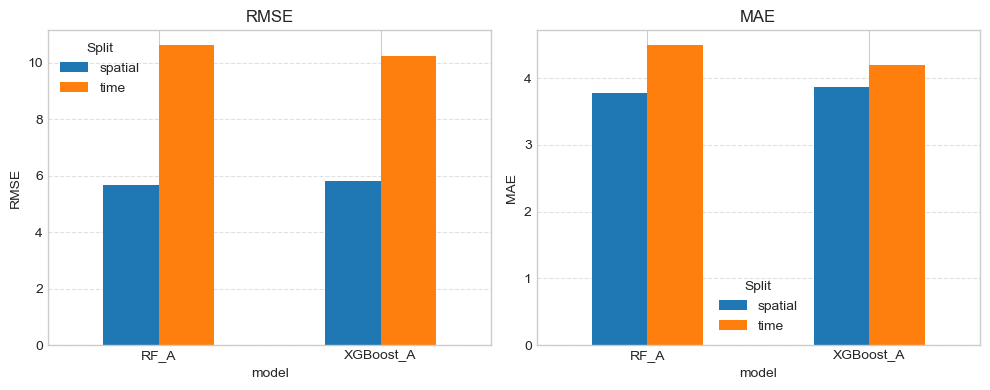

In [15]:
plot_a = metrics_a.melt(
    id_vars=["split", "model"],
    value_vars=["RMSE", "MAE"],
    var_name="metric",
    value_name="value",
)

fig = px.bar(
    plot_a,
    x="model",
    y="value",
    color="split",
    facet_col="metric",
    barmode="group",
    title="Model A — RMSE and MAE by split",
)
fig.update_layout(template="plotly_white", paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)")
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.write_html("images/modela_matrix_comparison.html", include_plotlyjs="cdn")
fig.show()


## Model B — Random Forest (Environmental + PM2.5 History + Lagged Pollutants)

Accuracy benchmark. Adds PM2.5 lags, rolling stats, and lagged co-pollutants on top of all Model A features.
Comparing A vs B shows how much pollution memory and co-pollutant history improves forecasting.

In [16]:
# Model B feature set
features_b = [
    "PM2_5_lag1", "PM2_5_lag2", "PM2_5_lag3", "PM2_5_roll3_mean", "PM2_5_roll3_std",
    "PM10_lag1", "NO2_lag1", "O3_lag1",
    "Temp_Mean", "Wind_Speed", "Precipitation",
    "Temp_Mean_lag1", "Wind_Speed_lag1", "Precipitation_lag1",
    "month_sin", "month_cos",
    "Altitude", "Latitude", "Longitude",
    "Green_Ratio", "Population_Density",
    "Station_Type", "Station_Area",
]
features_b = [c for c in features_b if c in df_model.columns]
X_b = df_model[features_b].copy()

print("Model B features:", len(features_b))
print(features_b)
print("Model B X shape:", X_b.shape)

Model B features: 23
['PM2_5_lag1', 'PM2_5_lag2', 'PM2_5_lag3', 'PM2_5_roll3_mean', 'PM2_5_roll3_std', 'PM10_lag1', 'NO2_lag1', 'O3_lag1', 'Temp_Mean', 'Wind_Speed', 'Precipitation', 'Temp_Mean_lag1', 'Wind_Speed_lag1', 'Precipitation_lag1', 'month_sin', 'month_cos', 'Altitude', 'Latitude', 'Longitude', 'Green_Ratio', 'Population_Density', 'Station_Type', 'Station_Area']
Model B X shape: (3554, 23)


### Model B — Time split

In [17]:
def make_preprocessor_b(feature_list):
    num_cols_b = [c for c in feature_list if pd.api.types.is_numeric_dtype(df_model[c])]
    cat_cols_b = [c for c in feature_list if c not in num_cols_b]
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols_b),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols_b),
    ])

pre_b = make_preprocessor_b(features_b)

# Time split
X_train_b_t = X_b.loc[time_train_mask]
X_test_b_t = X_b.loc[time_test_mask]
y_train_t = y.loc[time_train_mask]
y_test_t = y.loc[time_test_mask]

rf_b = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1)),
])
rf_b.fit(X_train_b_t, y_train_t)
pred_rf_b_t = rf_b.predict(X_test_b_t)
m_rf_b_t = reg_metrics(y_test_t, pred_rf_b_t)
print("Model B time split:", m_rf_b_t)

Model B time split: {'MAE': 4.306216265164847, 'RMSE': 10.4588766577354, 'R2': 0.29024524666100826}


### Model B — Spatial split

In [18]:
X_train_b_s = X_b.iloc[tr_idx]
X_test_b_s = X_b.iloc[te_idx]
y_train_s = y.iloc[tr_idx]
y_test_s = y.iloc[te_idx]

rf_b_s = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1)),
])
rf_b_s.fit(X_train_b_s, y_train_s)
pred_rf_b_s = rf_b_s.predict(X_test_b_s)
m_rf_b_s = reg_metrics(y_test_s, pred_rf_b_s)
print("Model B spatial split:", m_rf_b_s)

Model B spatial split: {'MAE': 2.90375583858239, 'RMSE': 4.746541101053825, 'R2': 0.6712502755727932}


In [19]:
metrics_b = pd.DataFrame([
    {"split": "time",    "model": "RandomForest_B", **m_rf_b_t},
    {"split": "spatial", "model": "RandomForest_B", **m_rf_b_s},
])
display(metrics_b)
metrics_b.to_csv("model_output/modelb_results.csv", index=False)
print("Saved to model_output/modelb_results.csv")

,split,model,MAE,RMSE,R2
0,time,RandomForest_B,4.306216,10.458877,0.290245
1,spatial,RandomForest_B,2.903756,4.746541,0.671250


Saved to model_output/modelb_results.csv


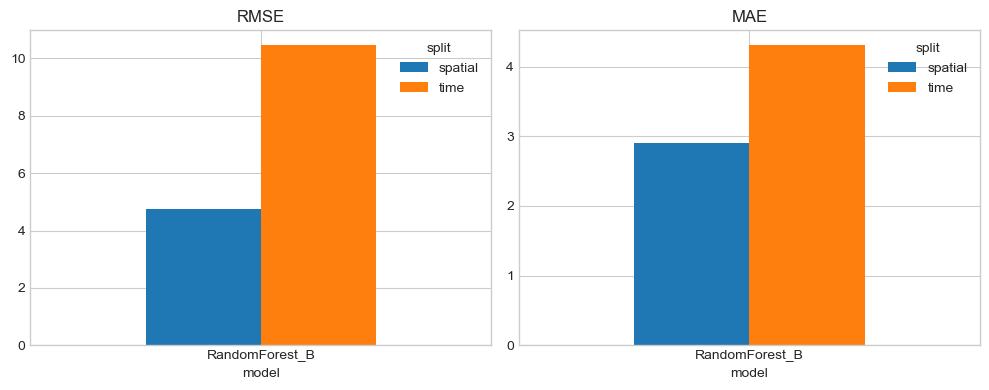

In [20]:
plot_b = metrics_b.melt(
    id_vars=["split", "model"],
    value_vars=["RMSE", "MAE"],
    var_name="metric",
    value_name="value",
)

fig = px.bar(
    plot_b,
    x="model",
    y="value",
    color="split",
    facet_col="metric",
    barmode="group",
    title="Model B — RMSE and MAE by split",
)
fig.update_layout(template="plotly_white", paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)")
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.write_html("images/modelb_metrics.html", include_plotlyjs="cdn")
fig.show()


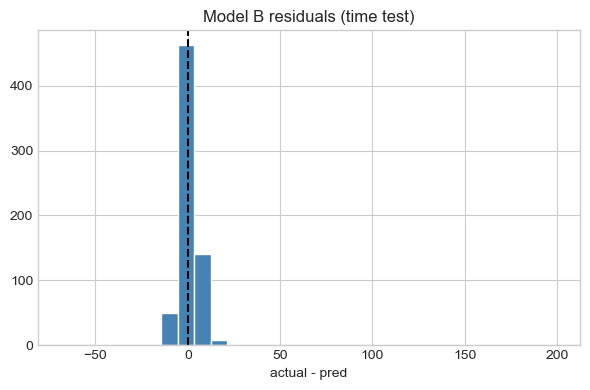

In [21]:
r = y_test_t.values - pred_rf_b_t
fig = px.histogram(
    x=r,
    nbins=30,
    title="Model B residuals (time test)",
    labels={"x": "actual - pred", "y": "count"},
)
fig.add_vline(x=0, line_dash="dash", line_color="black")
fig.update_layout(template="plotly_white", paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)")
fig.write_html("images/modelb_residuals_time.html", include_plotlyjs="cdn")
fig.show()


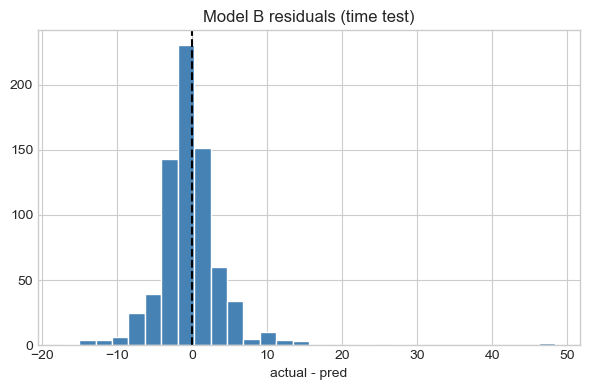

In [22]:
r = y_test_s.values - pred_rf_b_s
fig = px.histogram(
    x=r,
    nbins=30,
    title="Model B residuals (spatial test)",
    labels={"x": "actual - pred", "y": "count"},
)
fig.add_vline(x=0, line_dash="dash", line_color="black")
fig.update_layout(template="plotly_white", paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)")
fig.write_html("images/modelb_residuals_space.html", include_plotlyjs="cdn")
fig.show()


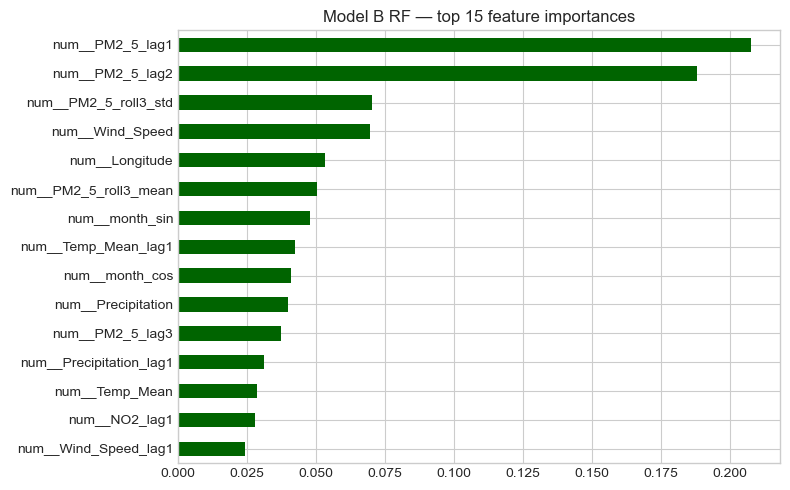

In [23]:
names = rf_b.named_steps["preprocess"].get_feature_names_out()
imp = pd.Series(rf_b.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).head(15)

imp_plot = imp.sort_values().reset_index()
imp_plot.columns = ["feature", "importance"]

fig = px.bar(
    imp_plot,
    x="importance",
    y="feature",
    orientation="h",
    title="Model B RF — top 15 feature importances",
)
fig.update_layout(template="plotly_white", paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)")
fig.write_html("images/modelb_importance.html", include_plotlyjs="cdn")
fig.show()


Top 10 SHAP features (mean |SHAP|):


,feature,mean_abs_shap
0,num__PM2_5_lag1,3.589224
15,num__month_cos,1.480371
14,num__month_sin,1.099605
18,num__Longitude,0.715171
1,num__PM2_5_lag2,0.661628
11,num__Temp_Mean_lag1,0.503557
10,num__Precipitation,0.462350
8,num__Temp_Mean,0.431551
3,num__PM2_5_roll3_mean,0.430128
6,num__NO2_lag1,0.326172


Saved to model_output/modelb_shap_importance.csv


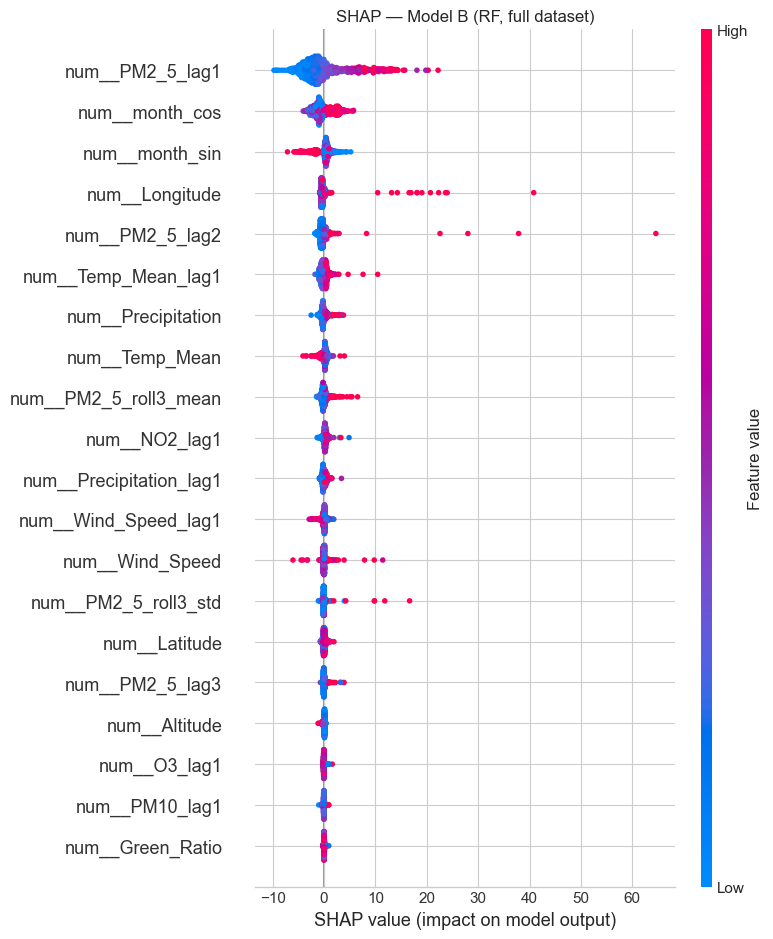

In [24]:
import scipy.sparse as sp
import shap

rf_b_full = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1)),
])
rf_b_full.fit(X_b, y)

Xp = rf_b_full.named_steps["preprocess"].transform(X_b)
if sp.issparse(Xp):
    Xp = Xp.toarray()
Xp = np.asarray(Xp, dtype=np.float64)

rng = np.random.RandomState(42)
idx = rng.choice(Xp.shape[0], size=min(800, Xp.shape[0]), replace=False)
Xs = Xp[idx]

explainer = shap.TreeExplainer(rf_b_full.named_steps["model"])
sv = explainer.shap_values(Xs)
fn = rf_b_full.named_steps["preprocess"].get_feature_names_out()

# Global SHAP importance (numeric)
mean_abs_shap = np.abs(sv).mean(axis=0)
shap_importance_df = (
    pd.DataFrame({"feature": fn, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
)

# 1) Per-point beeswarm direction view in Plotly
top_n = 15
top_features = shap_importance_df.head(top_n)["feature"].tolist()
feat_to_rank = {f: i for i, f in enumerate(top_features)}

long_df = pd.DataFrame({
    "feature": np.repeat(fn, Xs.shape[0]),
    "shap_value": sv.T.flatten(),
    "feature_value": Xs.T.flatten(),
})
long_df = long_df[long_df["feature"].isin(top_features)].copy()
long_df["feature_rank"] = long_df["feature"].map(feat_to_rank)

# Normalize values per feature for SHAP-like red/blue coloring
long_df["feature_value_norm"] = long_df.groupby("feature")["feature_value"].transform(
    lambda s: (s - s.mean()) / (s.std() + 1e-9)
)

# Vertical jitter creates beeswarm effect around each feature row
jitter_rng = np.random.RandomState(42)
long_df["y_jitter"] = long_df["feature_rank"] + jitter_rng.uniform(-0.28, 0.28, size=len(long_df))

fig_swarm = px.scatter(
    long_df,
    x="shap_value",
    y="y_jitter",
    color="feature_value_norm",
    color_continuous_scale=[[0.0, "#1f6bff"], [1.0, "#ff4fa3"]],
    opacity=0.65,
    title=f"SHAP — Model B (RF): per-point beeswarm direction view (top {top_n} features)",
    labels={"shap_value": "SHAP value (impact on PM2.5)", "feature_value_norm": "feature value (z-score)"},
    hover_data={"feature": True, "feature_value": ':.3f', "shap_value": ':.3f', "y_jitter": False},
)
fig_swarm.update_traces(marker={"size": 6})
fig_swarm.update_layout(
    template="plotly_white",
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    yaxis=dict(
        title="",
        tickmode="array",
        tickvals=list(range(top_n)),
        ticktext=top_features,
        autorange="reversed",
    ),
)
fig_swarm.add_vline(x=0, line_dash="dash", line_color="black")
fig_swarm.write_html("images/modelb_shap_beeswarm.html", include_plotlyjs="cdn")
fig_swarm.show()

# 2) Top 15 features in Plotly
top15 = shap_importance_df.head(15).copy().iloc[::-1]
fig_top = px.bar(
    top15,
    x="mean_abs_shap",
    y="feature",
    orientation="h",
    title="SHAP — Model B (RF): top 15 mean |SHAP|",
)
fig_top.update_layout(template="plotly_white", paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)")
fig_top.write_html("images/modelb_shap_top15.html", include_plotlyjs="cdn")
fig_top.show()

# 3) Summary table + export
top10_shap = shap_importance_df.head(10).copy()
print("Top 10 SHAP features (mean |SHAP|):")
display(top10_shap)
shap_importance_df.to_csv("model_output/modelb_shap_importance.csv", index=False)
print("Saved to model_output/modelb_shap_importance.csv")




### SHAP test (simple explanation)

SHAP helps us explain **why** Model B predicts higher or lower PM2.5 for each data point.

How it works:
- For each row, SHAP assigns a contribution value to every feature.
- A **positive SHAP value** means that feature pushes the prediction **up**.
- A **negative SHAP value** means that feature pushes the prediction **down**.
- Bigger absolute values mean stronger influence.

Why we need it:
- Random Forest is accurate but not directly interpretable.
- SHAP gives transparent feature-level evidence for the policy story.
- We use it to compare with Ridge signs (Model C) and check consistency across models.



## Model C — Ridge Regression (Linear Baseline)

Model C mirrors Part 3 style: train Ridge on the same Model B feature matrix, evaluate on both time and spatial splits, and report signed coefficients for interpretation.

How to read this section:
- Higher R2 and lower RMSE/MAE indicate better fit.
- Coefficient sign gives direction (positive increases predicted PM2.5, negative decreases it).
- Coefficients should be interpreted alongside SHAP because one-hot encoding and correlated variables can spread linear weights.

In [25]:
# Time split
ridge = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", Ridge(alpha=1.0, random_state=42)),
])
ridge.fit(X_train_b_t, y_train_t)
pred_ridge_t = ridge.predict(X_test_b_t)
m_ridge_t = reg_metrics(y_test_t, pred_ridge_t)
print("Model C (Ridge) time split:", m_ridge_t)

# Spatial split
ridge_s = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", Ridge(alpha=1.0, random_state=42)),
])
ridge_s.fit(X_train_b_s, y_train_s)
pred_ridge_s = ridge_s.predict(X_test_b_s)
m_ridge_s = reg_metrics(y_test_s, pred_ridge_s)
print("Model C (Ridge) spatial split:", m_ridge_s)

metrics_c = pd.DataFrame([
    {"split": "time", "model": "Ridge_C", **m_ridge_t},
    {"split": "spatial", "model": "Ridge_C", **m_ridge_s},
])
print("\nModel C metrics table:")
display(metrics_c)
metrics_c.to_csv("model_output/modelc_results.csv", index=False)
print("Saved to model_output/modelc_results.csv")

Model C (Ridge) time split: {'MAE': 4.843267546362268, 'RMSE': 10.933604206646043, 'R2': 0.22435155881818936}
Model C (Ridge) spatial split: {'MAE': 4.3143813691227315, 'RMSE': 6.095275914537192, 'R2': 0.4578772347262847}

Model C metrics table:


,split,model,MAE,RMSE,R2
0,time,Ridge_C,4.843268,10.933604,0.224352
1,spatial,Ridge_C,4.314381,6.095276,0.457877


Saved to model_output/modelc_results.csv


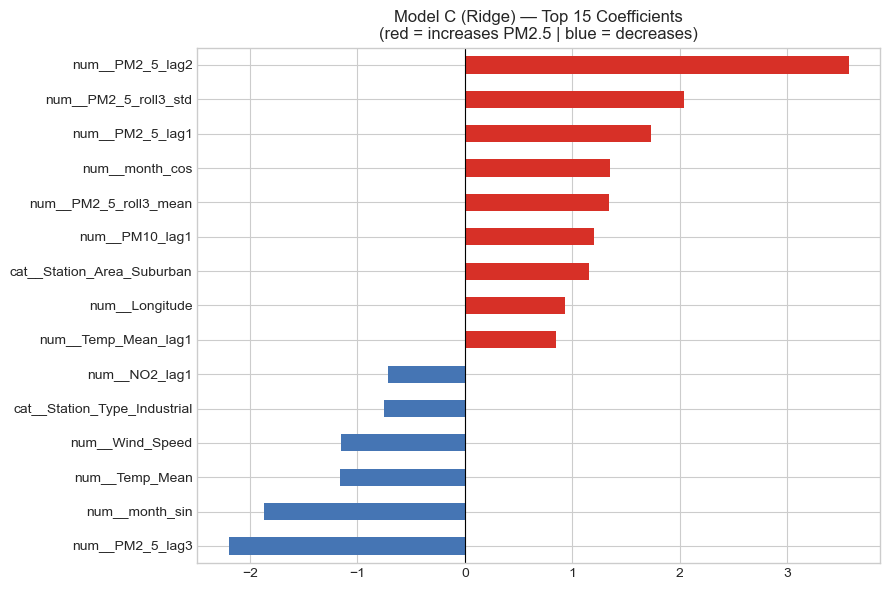

Top positive Ridge coefficients:


,coef
num__PM2_5_lag2,3.573585
num__PM2_5_roll3_std,2.039483
num__PM2_5_lag1,1.735138
num__month_cos,1.349500
num__PM2_5_roll3_mean,1.339937
num__PM10_lag1,1.198765
cat__Station_Area_Suburban,1.151081
num__Longitude,0.933631


Top negative Ridge coefficients:


,coef
num__PM2_5_lag3,-2.199792
num__month_sin,-1.866635
num__Temp_Mean,-1.161482
num__Wind_Speed,-1.155037
cat__Station_Type_Industrial,-0.753585
num__NO2_lag1,-0.717050
num__O3_lag1,-0.710916
num__Altitude,-0.685688


Saved to model_output/modelc_coefficients_sorted.csv


In [26]:
feat_names_c = ridge.named_steps["preprocess"].get_feature_names_out()
coef_full = pd.Series(ridge.named_steps["model"].coef_, index=feat_names_c)
coef = coef_full.sort_values(key=abs, ascending=False).head(15)

coef_plot = coef.sort_values().reset_index()
coef_plot.columns = ["feature", "coef"]
coef_plot["direction"] = np.where(coef_plot["coef"] >= 0, "increase", "decrease")

fig = px.bar(
    coef_plot,
    x="coef",
    y="feature",
    color="direction",
    orientation="h",
    title="Model C (Ridge) — Top 15 coefficients",
    color_discrete_map={"increase": "#d73027", "decrease": "#4575b4"},
)
fig.update_layout(template="plotly_white", paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)")
fig.add_vline(x=0, line_width=1, line_color="black")
fig.write_html("images/model_c_ridge_coeff.html", include_plotlyjs="cdn")
fig.show()

top_positive = coef_full.sort_values(ascending=False).head(8).rename("coef")
top_negative = coef_full.sort_values(ascending=True).head(8).rename("coef")

print("Top positive Ridge coefficients:")
display(top_positive.to_frame())
print("Top negative Ridge coefficients:")
display(top_negative.to_frame())

coef_full.sort_values(key=abs, ascending=False).to_csv("model_output/modelc_coefficients_sorted.csv", header=["coef"])
print("Saved to model_output/modelc_coefficients_sorted.csv")


- Red bars (positive) increase predicted PM2.5.
- Blue bars (negative) decrease predicted PM2.5.
- Larger absolute coefficients indicate stronger linear influence after preprocessing/scaling.

### Model B vs Model C — Feature Effect Comparison

This table compares:
- **Model B (RF + SHAP):** global importance (`mean_abs_shap`)
- **Model C (Ridge):** signed linear coefficient (`ridge_coef`)

How to read it:
- High `mean_abs_shap` means the feature matters a lot for Model B predictions.
- `ridge_coef` sign gives direction in Model C (positive increases PM2.5, negative decreases PM2.5).
- Features with high SHAP and stable Ridge sign are stronger candidates for reporting in the final story.

In [27]:
shap_cmp = shap_importance_df.set_index("feature").copy()
ridge_cmp = coef_full.rename("ridge_coef").to_frame()

comparison_bc = (
    shap_cmp
    .join(ridge_cmp, how="inner")
    .assign(
        abs_ridge_coef=lambda d: d["ridge_coef"].abs(),
        ridge_direction=lambda d: np.where(d["ridge_coef"] >= 0, "increase", "decrease"),
    )
    .sort_values("mean_abs_shap", ascending=False)
)

comparison_bc["rank_shap"] = np.arange(1, len(comparison_bc) + 1)
comparison_bc["rank_abs_ridge"] = comparison_bc["abs_ridge_coef"].rank(ascending=False, method="dense").astype(int)

print("Top 20 transformed features: Model B SHAP vs Model C Ridge")
display(comparison_bc.head(20))

comparison_bc.to_csv("model_output/modelb_modelc_feature_comparison.csv")
print("Saved to model_output/modelb_modelc_feature_comparison.csv")

Top 20 transformed features: Model B SHAP vs Model C Ridge


,mean_abs_shap,ridge_coef,abs_ridge_coef,ridge_direction,rank_shap,rank_abs_ridge
num__PM2_5_lag1,3.589224,1.735138,1.735138,increase,1,5
num__month_cos,1.480371,1.349500,1.349500,increase,2,6
num__month_sin,1.099605,-1.866635,1.866635,decrease,3,4
num__Longitude,0.715171,0.933631,0.933631,increase,4,12
num__PM2_5_lag2,0.661628,3.573585,3.573585,increase,5,1
num__Temp_Mean_lag1,0.503557,0.845714,0.845714,increase,6,13
num__Precipitation,0.462350,0.412382,0.412382,increase,7,24
num__Temp_Mean,0.431551,-1.161482,1.161482,decrease,8,9
num__PM2_5_roll3_mean,0.430128,1.339937,1.339937,increase,9,7
num__NO2_lag1,0.326172,-0.717050,0.717050,decrease,10,15


Saved to model_output/modelb_modelc_feature_comparison.csv


We prioritize rows with high mean_abs_shap and large abs_ridge_coef for stronger cross-model signals. 'ridge_direction' provides a simple directional summary from the linear baseline.

**Similarities**

Strong cross-model signals (high SHAP + high |Ridge|)

- num__PM2_5_lag1: SHAP = 3.589 (rank 1), Ridge = +1.735 (|coef| rank 5)
→ strongest global driver in RF and clearly positive in Ridge.
- num__month_sin: SHAP = 1.100 (rank 3), Ridge = -1.867 (|coef| rank 4)
→ strong seasonal effect with negative linear direction.
- num__month_cos: SHAP = 1.480 (rank 2), Ridge = +1.350 (|coef| rank 6)
→ also strong seasonality, positive linear direction.
- num__PM2_5_roll3_mean: SHAP = 0.430 (rank 9), Ridge = +1.340 (rank 7)
→ medium RF importance, strong positive linear memory effect.
- num__PM10_lag1: SHAP = 0.096 (rank 19), Ridge = +1.199 (rank 8)
→ weak in RF but relatively strong linear positive contribution.

Weak cross-model signals (high SHAP + high |Ridge|)
- num__Green_Ratio: SHAP = 0.050 (rank 20), Ridge = -0.072 (rank 26)
→ very weak in both models in current setup.
- num__Latitude: SHAP = 0.187 (rank 15), Ridge = +0.471 (rank 23)
→ modest/low effect.
- num__Precipitation: SHAP = 0.462 (rank 7), Ridge = +0.412 (rank 24)
→ moderate in RF, small linear coefficient.

**Differences**
- num__PM2_5_lag2: SHAP = 0.662 (rank 5) but Ridge = +3.574 (rank 1)
→ Ridge gives this very large weight; likely shared signal with other lag features.
- num__PM2_5_lag3: SHAP = 0.162 (rank 16) but Ridge = -2.200 (rank 2)
→ large negative coefficient despite low RF importance (classic collinearity pattern with lag1/lag2/rolling stats).
- num__PM2_5_roll3_std: SHAP = 0.198 (rank 14) but Ridge = +2.039 (rank 3)
→ linear model emphasizes volatility more than RF SHAP does.

We notice a very important problem here - collinearity.